In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

In [14]:
sales_data = pd.read_csv(r'D:\My Paython\Retail sales\retail_sales_dataset.csv')
sales_data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [15]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [16]:
sales_data.isnull().sum()   

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [17]:
sales_data["Date"] = pd.to_datetime(sales_data["Date"])
sales_data["Month"] = sales_data["Date"].dt.month
sales_data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5


In [ ]:
sales_by_product_category = sales_data.groupby("Product Category")["Total Amount"].sum().reset_index()


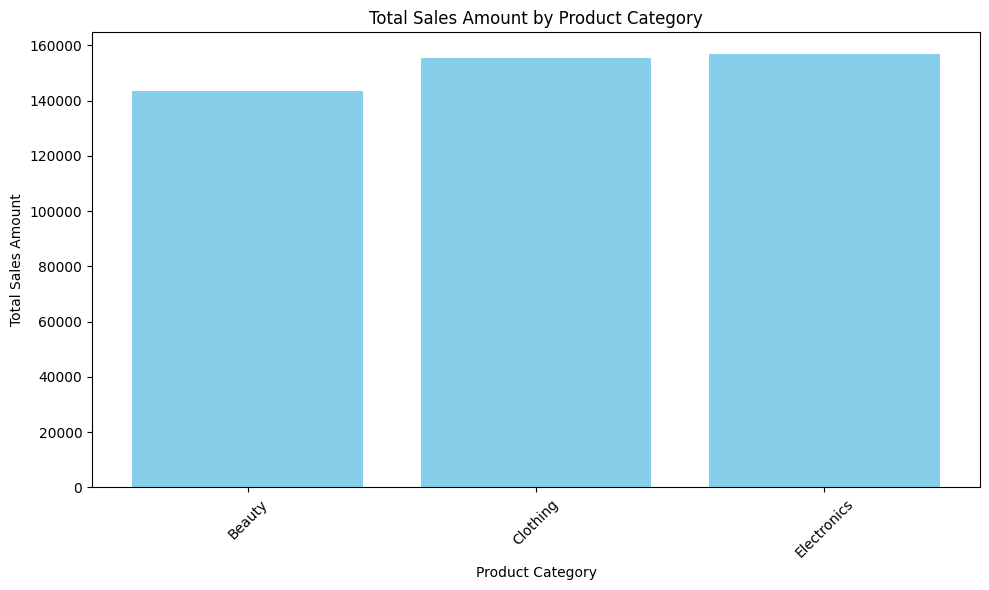

In [31]:
plt.figure(figsize=(10, 6))
plt.bar(sales_by_product_category["Product Category"], sales_by_product_category["Total Amount"], color='skyblue')
plt.xlabel("Product Category")      
plt.ylabel("Total Sales Amount")
plt.title("Total Sales Amount by Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
sales_by_gender = sales_data.groupby("Gender")["Total Amount"].sum().reset_index()
sales_by_gender

,Gender,Total Amount
0,Female,232840
1,Male,223160


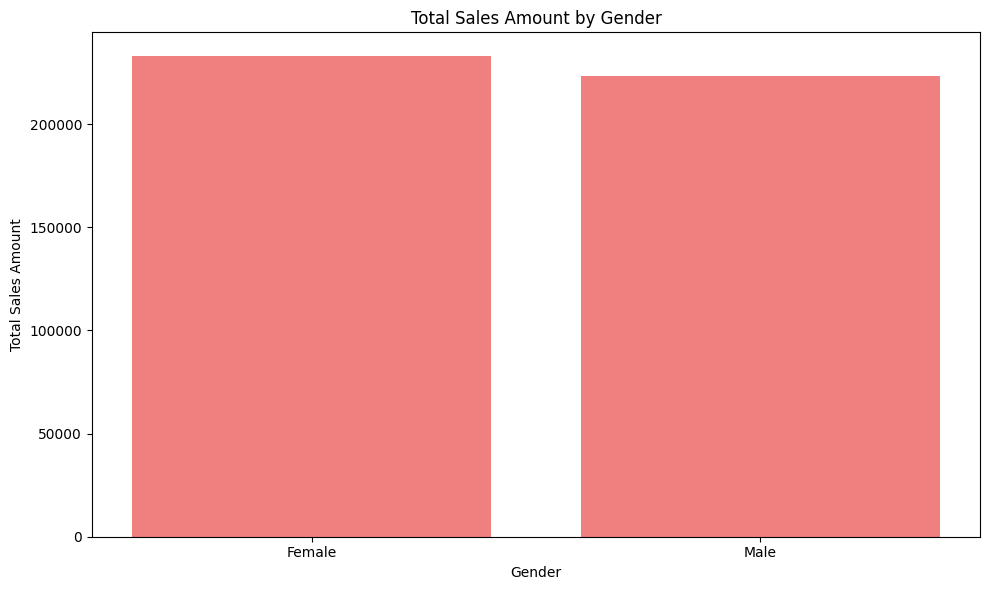

In [34]:
plt.figure(figsize=(10, 6))
plt.bar(sales_by_gender["Gender"], sales_by_gender["Total Amount"], color='lightcoral')
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales Amount by Gender")
plt.tight_layout()
plt.show()

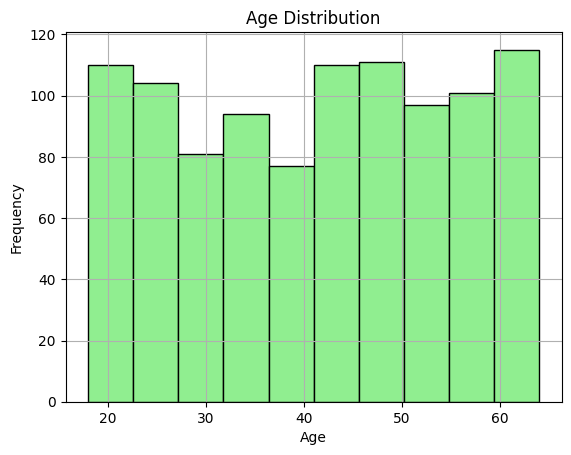

In [39]:
sales_data["Age"].hist(bins=10, color='lightgreen', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

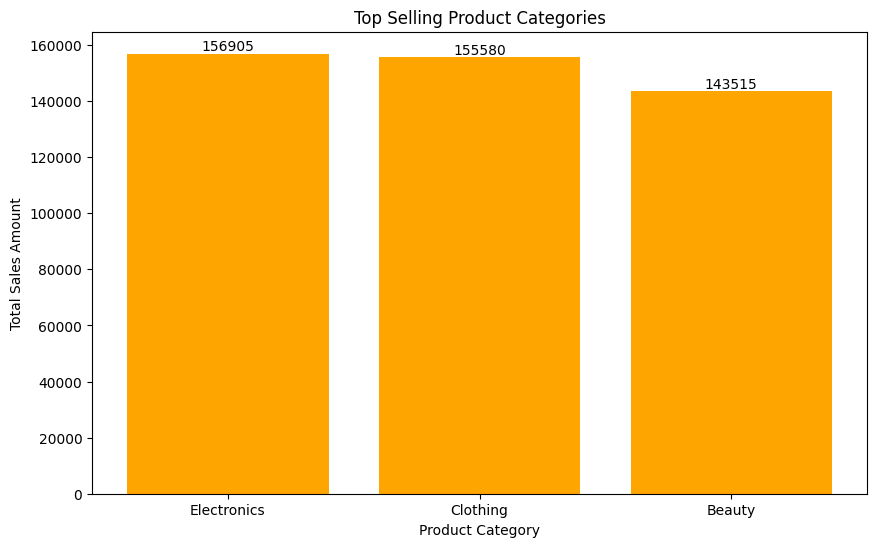

In [ ]:
best_selling_products = sales_data.groupby("Product Category")["Total Amount"].sum().reset_index().sort_values(by="Total Amount", ascending=False).head(10)
best_selling_products
plt.figure(figsize=(10, 6))

ax = plt.gca() 

bars = ax.bar(
    best_selling_products["Product Category"],
    best_selling_products["Total Amount"],
    color="orange"
)

ax.bar_label(bars)
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.title("Top Selling Product Categories")
plt.show()

Electronics achieved the highest Sales among all product categories.#

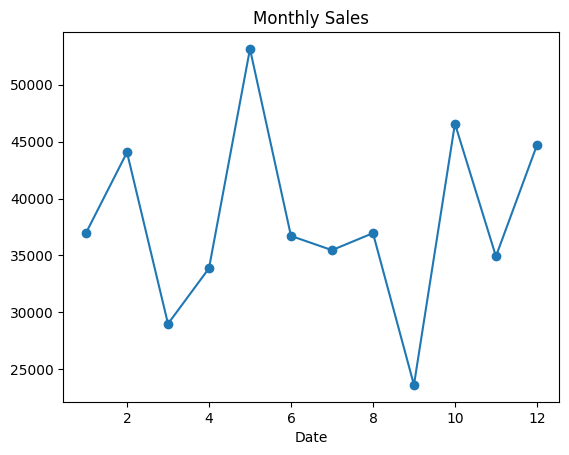

In [ ]:

sales_data_by_month = sales_data.groupby("Month")["Total Amount"].sum().reset_index()
sales_data_by_month.sort_values(by="Month", inplace=True)
sales_data["Date"] = pd.to_datetime(sales_data["Date"])

monthly_sales = sales_data.groupby(sales_data["Date"].dt.month)["Total Amount"].sum()

monthly_sales.plot(marker="o")
plt.title("Monthly Sales")
plt.show()

Sales peaked in May, indicating a potential seasonal trend


In [54]:
category_sales = sales_data.groupby("Product Category")["Total Amount"].sum()

(category_sales / category_sales.sum() * 100).round(2)


Product Category
Beauty         31.47
Clothing       34.12
Electronics    34.41
Name: Total Amount, dtype: float64

Electronics achieved the highest revenue among all product categories.

In [59]:
sales_data["Age Group"] = pd.cut(
    sales_data["Age"],
    bins=[18,25,35,45,55,100],
    labels=["18-25","26-35","36-45","46-55","56+"]
)
age_group_sales = sales_data.groupby("Age Group")["Total Amount"].sum().reset_index()
age_group_sales


,Age Group,Total Amount
0,18-25,73335
1,26-35,98480
2,36-45,91870
3,46-55,100690
4,56+,80410


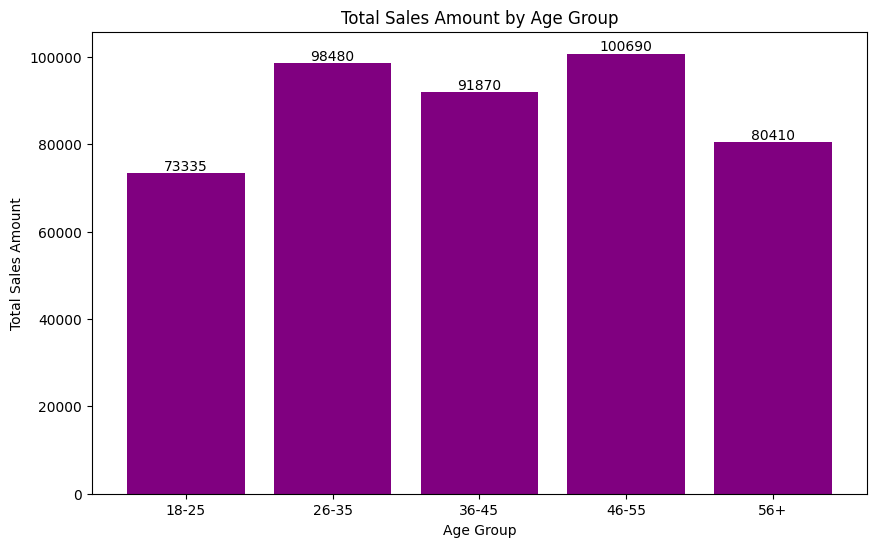

In [60]:
age_group_sales = sales_data.groupby("Age Group")["Total Amount"].sum().reset_index()
age_group_sales
plt.figure(figsize=(10, 6))
ax = plt.gca()  
bars = ax.bar(
    age_group_sales["Age Group"],
    age_group_sales["Total Amount"],
    color="purple"
)
ax.bar_label(bars)
plt.xlabel("Age Group")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales Amount by Age Group")
plt.show()

Customers were divided into age groups to make the analysis easier and more meaningful. This allows us to compare purchasing behavior across different age segments and identify the most valuable customer groups.

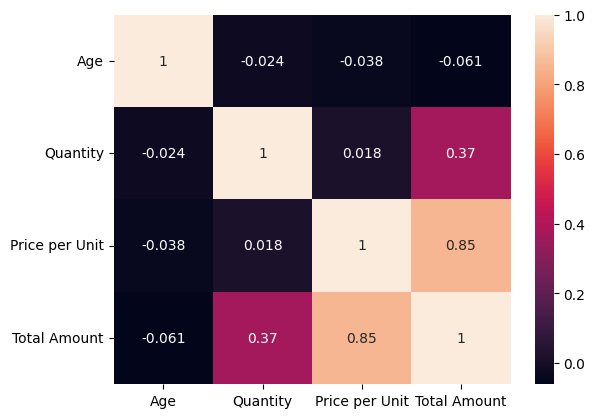

In [69]:
import seaborn as sns

corr = sales_data[["Age","Quantity","Price per Unit","Total Amount"]].corr()

sns.heatmap(corr, annot=True)
plt.show()

There is a strong positive correlation between Quantity and Total Amount, indicating that customers who purchase more items tend to generate higher sales revenue.